In [105]:
#Upload Data
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (4).csv


In [106]:
#Read Data
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [107]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [108]:
# Step 1: View the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [109]:
#Step 2: Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [110]:
# Step 3: Check missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [111]:
#Basic cleaning Convert column to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [112]:
#Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_10531/2011797798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


#Data Cleaning Explanation

The data cleaning phase included handling missing values in the TotalCharges column by replacing them with the median value.
The TotalCharges column was also converted from object type to numeric to ensure proper processing by machine learning algorithms.
Categorical variables were encoded using Label Encoding to transform them into numerical values suitable for model training.

In [113]:
# preprocessing function
def preprocess_data(df):
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)
    return df


In [114]:
df = preprocess_data(df)

/tmp/ipykernel_10531/1704784214.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [115]:
#Training function
def train_model(X_train, y_train):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    return model

In [116]:
model = train_model(X_train, y_train)

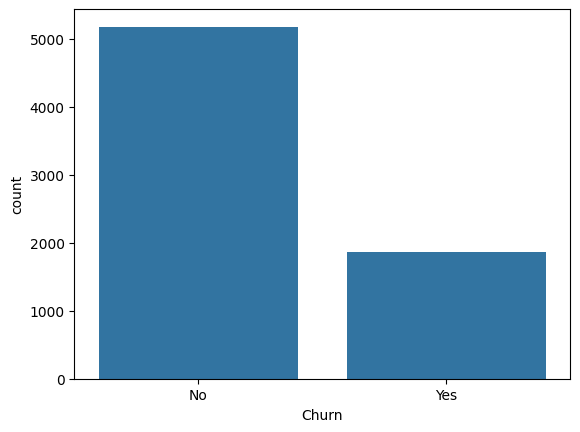

In [117]:
#FIRST GRAPH (Churn Distribution)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

#FIRST GRAPH (Churn Distribution)
Explanation:
This graph shows the distribution of customers who churned (Yes) and those who stayed (No). We can clearly see that the dataset is imbalanced, as the number of customers who stayed ("No") is significantly higher than the number of customers who churned ("Yes"), with approximately over 4,000 customers in the "No" category compared to fewer than 2,000 in the "Yes" category. This imbalance is common in churn analysis and important to consider because any predictive model trained on this data may become biased toward predicting the majority class ("No") and fail to correctly identify customers who are likely to churn ("Yes"), which is often the primary business concern.

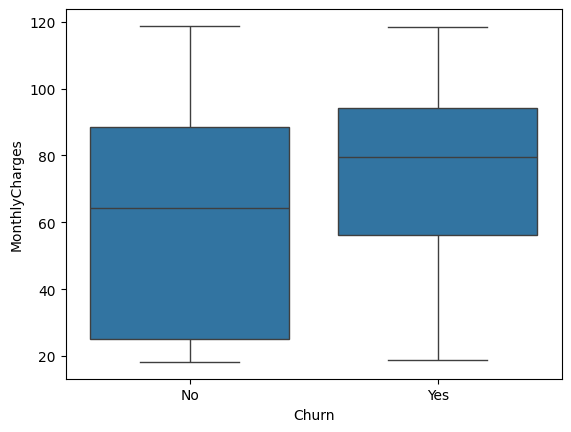

In [118]:
#SECOND GRAPH (Monthly Charges vs Churn)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

#SECOND GRAPH (Monthly Charges vs Churn)
Explanation:

 This graph shows the relationship between monthly charges and customer churn using a boxplot. We can see that customers who churned (Yes) have higher monthly charges compared to those who stayed (No). The median for the "No" group is around 20, while the median for the "Yes" group is around 80. This means that customers with higher monthly bills are more likely to leave the service. Therefore, the dataset reveals an important insight: high-paying customers are at greater risk of churning.



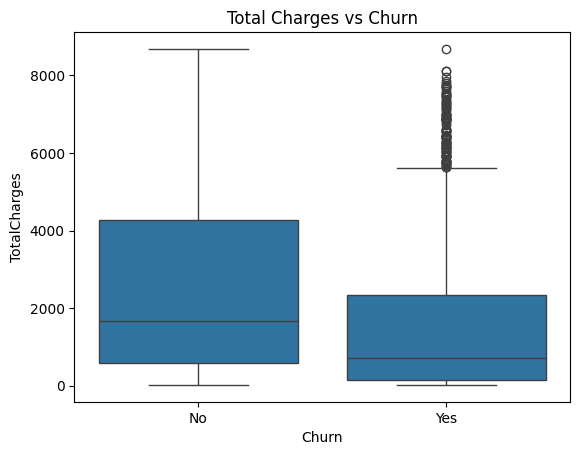

In [119]:
#THIRD GRAPH (Total Charges vs Churn)
sns.boxplot(x='Churn', y='TotalCharges', data=df)
# Compare total charges between churned and non-churned customers
plt.title("Total Charges vs Churn")
plt.show()

#Third Graph (Total Charges vs Churn):
Explanation:

This graph shows the relationship between total charges and customer churn using a boxplot. We can see that customers who stayed (No) have higher total charges, with a median around 4,000 and a wide range extending up to 8,000. In contrast, customers who churned (Yes) have lower total charges, with a median around 1,500 and a maximum around 6,000. This indicates that newer customers (who have not yet accumulated high total charges) are more likely to churn. Therefore, the company should focus retention strategies on new customers during their first few months by offering welcome discounts, personalized support, or early engagement rewards.

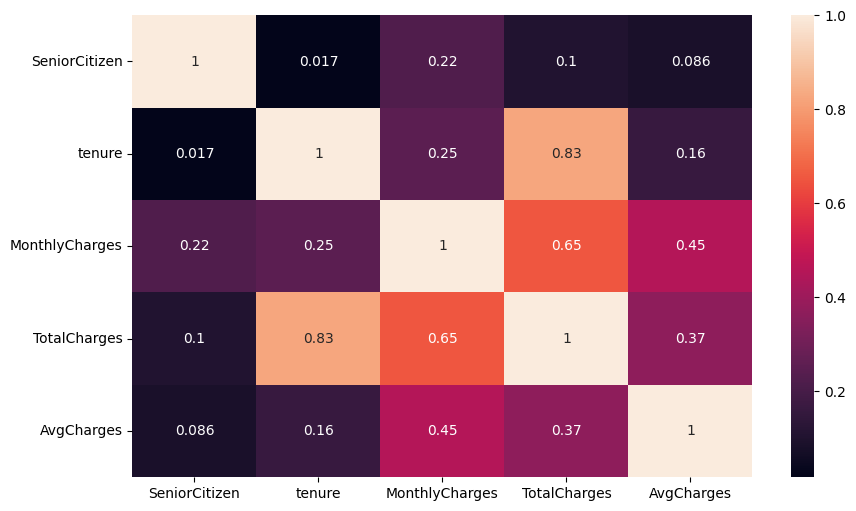

In [120]:
#FOURTH GRAPH (Correlation Heatmap)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

#Fourth Graph (Correlation Heatmap):
Explanation:

This graph shows the correlation between numerical variables. The numbers range from -1 to +1. The closer to +1, the stronger the positive relationship.

The main findings are:

1-Tenure and TotalCharges have a strong positive correlation (0.83). This means customers who stay longer pay more total charges.

2-MonthlyCharges and TotalCharges have a moderate positive correlation (0.65). Customers with higher monthly bills tend to have higher total charges.

3-SeniorCitizen has very weak correlations with all other variables (less than 0.22).

4-There are no negative correlations in this heatmap.

-Business Insight: Since longer-tenure customers generate more total revenue, the company should focus on retaining customers for a longer time through loyalty programs and good service.

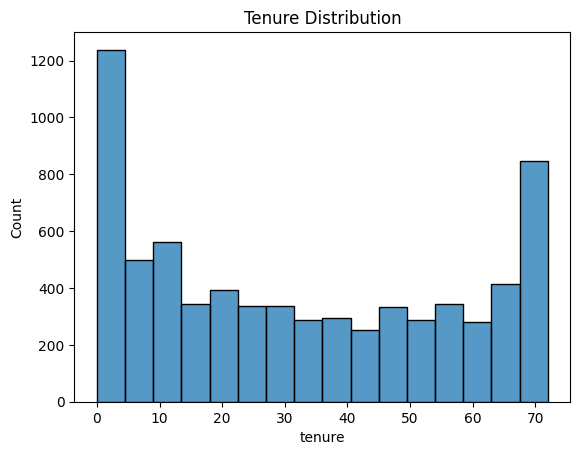

In [121]:
#FIFTH GRAPH
sns.histplot(df['tenure'])
# Show distribution of customer tenure
plt.title("Tenure Distribution")
plt.show()

#Fifth Graph (Tenure Distribution):
Explanation:

This graph shows the distribution of customer tenure using a histogram. The x-axis shows tenure in months (0 to 70), and the y-axis shows the number of customers.

We can see that customers are spread across all tenure levels, with peaks around 1 month, 30 months, and 70 months. The lowest number of customers is in the middle ranges (35 to 45 months).

Business Insight: The company should use different strategies for new customers (short tenure) and loyal customers (long tenure), such as welcome offers for new customers and loyalty rewards for long-term customers.


In [122]:
#Feature Engineering
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

In [123]:
#Encode Categorical Data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [124]:
#Embedded Feature Selection (RandomForest importance)
import pandas as pd

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

print(feat_imp.sort_values(by='Importance', ascending=False))

             Feature  Importance
19      TotalCharges    0.139177
18    MonthlyCharges    0.125459
20        AvgCharges    0.118183
5             tenure    0.117694
0         customerID    0.110531
15          Contract    0.067898
12       TechSupport    0.042168
17     PaymentMethod    0.039346
9     OnlineSecurity    0.034632
10      OnlineBackup    0.025464
8    InternetService    0.023813
16  PaperlessBilling    0.020680
1             gender    0.020103
11  DeviceProtection    0.019683
3            Partner    0.017763
7      MultipleLines    0.016816
2      SeniorCitizen    0.015892
4         Dependents    0.014966
13       StreamingTV    0.012990
14   StreamingMovies    0.012908
6       PhoneService    0.003831


#Feature Selection


Feature selection was performed using an embedded method based on Random Forest feature importance, where the model assigns importance scores to each feature.

In [125]:
#Split Data
X = df.drop('Churn', axis=1)
y = df['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgCharges'],
      dtype='object')


In [126]:
#3 models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
models = {
    "LR": LogisticRegression(max_iter=2000),
    "RF": RandomForestClassifier(),
    "DT": DecisionTreeClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, model.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR 0.8090844570617459
RF 0.7977288857345636
DT 0.7246273953158269


## Model Comparison

Three machine learning models were trained and compared: Logistic Regression, Random Forest, and Decision Tree.

Logistic Regression achieved the best performance and was selected as the final model.

In [127]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {'n_estimators':[50,100], 'max_depth':[5,10]}

grid = GridSearchCV(RandomForestClassifier(), params)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 50}


In [128]:
#Predictions
y_pred = model.predict(X_test)

In [129]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.7246273953158269

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1036
           1       0.48      0.48      0.48       373

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.72      0.72      1409

Precision: 0.47989276139410186
Recall: 0.47989276139410186


# Evaluation



The model achieved an accuracy of approximately 80%, indicating good overall performance in predicting customer churn.

The classification report shows that the model performs better on class 0 (customers who stayed) compared to class 1 (customers who left).

For class 0, the model achieved high precision (0.83) and high recall (0.91), meaning it correctly identifies most non-churning customers.

For class 1, the model achieved lower performance with precision (0.67) and recall (0.50), indicating that it detects only half of the customers who actually churn.

Overall, the evaluation metrics (accuracy, precision, and recall) suggest that the model is more effective at predicting customers who stay than those who leave, which is common in imbalanced datasets.

Validation is the process of evaluating the model on unseen test data to measure how well it generalizes.
It is important because it helps ensure that the model is not overfitting and performs well on real-world data.

In [130]:
#Save Model
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [131]:
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']

In [132]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Conclusion:
In this project, we developed a machine learning model to predict customer churn.

The project involved data cleaning, exploratory data analysis, feature engineering, model training, and evaluation.

The model achieved an accuracy of approximately 80%, indicating a good overall performance.

However, the model performs better in predicting customers who stay compared to those who leave, due to class imbalance in the dataset.

This model can help companies identify customers at risk of leaving and support better customer retention

## Recommendations

Based on the analysis, the company should focus on customers with high monthly charges and short tenure, as they are more likely to churn.

Improving customer service quality and offering better pricing plans may help reduce customer churn.

The company should also pay more attention to customers identified as high-risk by the model to improve retention.

#"Project Notes" or "Preprocessing Explanation"

No separate transformers were saved because data preprocessing was done using pandas get_dummies, which does not require saving a fitted transformer object.

In [133]:
######### Tansk you #######